# Guía de Ejercicios 1 — Inteligencia Artificial

## Modelos gráficos probabilísticos con PyMC

Sergio Hernández — `shernandez@ucm.cl` — Universidad Católica del Maule

---

En esta guía trabajaremos con **redes bayesianas**: representación de la
incertidumbre mediante grafos dirigidos acíclicos, independencia condicional e
inferencia diagnóstica.

La guía original usa `pgmpy`, que manipula tablas de probabilidad conjunta.
Aquí usamos **PyMC**, que es una biblioteca de *programación probabilística*:
se declara un **modelo generativo** y todas las probabilidades se estiman
**simulando** casos a partir de él.

| `pgmpy` | PyMC |
|---|---|
| `JointProbabilityDistribution([...])` | `pm.Categorical` sobre los estados conjuntos |
| `d.marginal_distribution(['A'])` | frecuencia relativa en la muestra |
| `d.check_independence(['A'],['B'])` | `independencia_mc(muestra, 'A', 'B')` |
| `BayesianModel([('A','C'), ...])` | `pm.Model` con `pm.Bernoulli` anidadas |
| `model.fit(datos)` | `pm.sample` con priors Beta sobre las CPT |
| `model.is_active_trail('A','B')` | `camino_activo(aristas, 'A', 'B')` |

### El método: simular y contar

Un modelo generativo permite fabricar casos. Para estimar $P(A, B)$ se simulan
cien mil pacientes, se cuenta en qué fracción ocurren ambos eventos, y esa
fracción **es** la estimación. Para condicionar en evidencia, se descartan los
casos que no la cumplen y se cuenta sobre el resto.

La ventaja: es el mismo procedimiento para tres variables o para tres mil, y no
requiere fórmulas nuevas. El costo: toda estimación trae **error de muestreo**,
y hay que saber cuánto.

Por eso, en cada sección compararemos la estimación con el valor **teórico**
calculado a mano. Esa comparación es el hilo conductor de toda la guía.

### Contenidos

1. Repaso de probabilidad — **Ejercicios 1 y 2**
2. Independencia condicional en grafos — **Ejercicios 3, 4 y 5**
3. Red Bayesiana *Asia* — **Ejercicios 6, 7 y 8**

Las celdas marcadas con `# TODO` son las que hay que completar. Cada ejercicio
termina con una verificación automática que imprime `OK` o `REVISAR`.

In [1]:
# Instalación (descomentar la primera vez)
# !pip install pymc networkx pandas matplotlib

import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import pytensor.tensor as pt
import networkx as nx

SEMILLA = 42
print("PyMC", pm.__version__)

PyMC 6.3.1


---
## 0. Caja de herramientas

Cuatro funciones bastan para toda la guía: simular, estimar, comparar contra la
teoría y chequear independencia.


> Ejecute la celda y siga adelante; no es necesario leerla en detalle la primera
> vez.

In [2]:
def muestrear(modelo, n=50_000, semilla=SEMILLA):
    # Simula n casos del modelo generativo (muestreo directo, sin MCMC).
    with modelo:
        previa = pm.sample_prior_predictive(draws=n, random_seed=semilla)
    nombres = ([v.name for v in modelo.free_RVs]
               + [d.name for d in modelo.deterministics])
    return pd.DataFrame({v: previa.prior[v].values.reshape(-1) for v in nombres}, dtype=np.bool)


def _mascara(df, condicion):
    m = pd.Series(True, index=df.index)
    for var, val in (condicion or {}).items():
        m &= df[var] == val
    return m


def p(df, evento, dado=None):
    # Estimacion Monte Carlo de P(evento | dado).
    # Devuelve (estimacion, error_estandar, n_casos_utilizados).
    base = _mascara(df, dado)
    n = int(base.sum())
    if n == 0:
        return np.nan, np.nan, 0
    est = float((base & _mascara(df, evento)).sum()) / n
    # Piso de varianza 1/n: si no ocurre ningun caso la varianza binomial es
    # cero y el error estandar quedaria nulo, lo que hace explotar cualquier
    # cociente. El piso es la correccion de continuidad habitual.
    se = np.sqrt(max(est * (1 - est), 1.0 / n) / n)
    return est, se, n


def comparar(nombre, teorico, estimacion, umbral=4.0):
    # Contrasta un valor teorico con su estimacion Monte Carlo.
    # El criterio es la distancia en errores estandar, no la diferencia bruta:
    # con n grande se exige mas precision que con n chico.
    est, se, n = estimacion
    z = abs(est - teorico) / se if se and se > 0 else np.inf
    marca = "OK      " if z < umbral else "REVISAR "
    print(f"[{marca}] {nombre:<26s} teoria {teorico:7.4f}   "
          f"MC {est:7.4f} +/- {2 * se:.4f}   n={n:>6d}   z={min(z, 999):5.1f}")
    return z < umbral


def independencia_mc(df, X, Y, Z=(), umbral=4.0, n_min=200):
    # Contrasta P(x,y|z) = P(x|z)P(y|z) en la muestra.
    # Devuelve (compatible_con_independencia, maxima_discrepancia_estandarizada).
    # La discrepancia se mide en errores estandar: una diferencia real pero mas
    # pequena que el ruido de muestreo NO se puede detectar con esta muestra.
    X = [X] if isinstance(X, str) else list(X)
    Y = [Y] if isinstance(Y, str) else list(Y)
    Z = [Z] if isinstance(Z, str) else list(Z)
    vals = {v: sorted(df[v].unique()) for v in X + Y + Z}
    z_max = 0.0
    for zc in (itertools.product(*[vals[v] for v in Z]) if Z else [()]):
        ev = dict(zip(Z, zc))
        if int(_mascara(df, ev).sum()) < n_min:
            continue
        for xc in itertools.product(*[vals[v] for v in X]):
            ex = dict(zip(X, xc))
            px = p(df, ex, ev)[0]
            for yc in itertools.product(*[vals[v] for v in Y]):
                ey = dict(zip(Y, yc))
                py = p(df, ey, ev)[0]
                pxy, se, _ = p(df, {**ex, **ey}, ev)
                if se and se > 0:
                    z_max = max(z_max, abs(pxy - px * py) / se)
    return (z_max < umbral), min(z_max, 999.0)


def tabla_2x2(df, A="A", B="B"):
    # Tabla 2x2 con marginales, en el formato del enunciado
    lineas = [f"{'':4s} {B:>8s} {B + chr(39):>8s} {'Marginal':>9s}"]
    for etiqueta, a in [(f"{A} ", 1), (f"{A}'", 0)]:
        pb = p(df, {A: a, B: 1})[0]
        pnb = p(df, {A: a, B: 0})[0]
        lineas.append(f"{etiqueta:4s} {pb:8.4f} {pnb:8.4f} {pb + pnb:9.4f}")
    cb = p(df, {B: 1})[0]
    cnb = p(df, {B: 0})[0]
    lineas.append(f"{'Marg':4s} {cb:8.4f} {cnb:8.4f} {cb + cnb:9.4f}")
    return "\n".join(lineas)


def d_separado(aristas, X, Y, Z=()):
    # Criterio GRAFICO (Bayes-Ball). No depende de los numeros de las CPT.
    g = nx.DiGraph(aristas)
    conv = lambda s: {s} if isinstance(s, str) else set(s)
    return nx.is_d_separator(g, conv(X), conv(Y), conv(Z))


def camino_activo(aristas, X, Y, Z=()):
    # Equivalente a BayesianModel.is_active_trail de pgmpy
    return not d_separado(aristas, X, Y, Z)


def cpt(tabla):
    # Tabla de probabilidad condicional indexable por los valores de los padres
    return pt.as_tensor(np.asarray(tabla, dtype="float64"))


def check(nombre, condicion, pista=""):
    print(f"[{'OK      ' if condicion else 'REVISAR '}] {nombre}"
          + (f"   -> {pista}" if (not condicion and pista) else ""))
    return bool(condicion)


print("Herramientas cargadas.")

Herramientas cargadas.


---
# 1. Repaso de probabilidad

**Convención de índices** (la misma de `pgmpy` y del enunciado): el estado `1`
significa que el evento **ocurre** y el estado `0` que **no ocurre**. Es decir
`A_1` = $A$ y `A_0` = $A'$.

Hay dos formas de declarar $P(A,B)$ en PyMC, y conviene tener ambas a mano:

In [3]:
def modelo_conjunto(p_joint):
    # Forma 1: la conjunta explicita, al estilo de pgmpy.
    # El estado k de la Categorical codifica el par (A,B) mediante k = 2*A + B,
    # de modo que p_joint sigue el orden [P(A0,B0), P(A0,B1), P(A1,B0), P(A1,B1)].
    with pm.Model() as modelo:
        AB = pm.Categorical("AB", p=np.asarray(p_joint))
        pm.Deterministic("A", AB // 2)
        pm.Deterministic("B", AB % 2)
    return modelo


def modelo_factorizado(p_A, p_B_dado_A, p_B_dado_noA):
    # Forma 2: P(A,B) = P(A) P(B|A), que es como se declara una red bayesiana.
    with pm.Model() as modelo:
        A = pm.Bernoulli("A", p_A)
        pm.Bernoulli("B", pt.switch(pt.eq(A, 1), p_B_dado_A, p_B_dado_noA))
    return modelo

In [4]:
np.__version__

'2.4.6'

## 1.1 Eventos mutuamente excluyentes

Dos eventos son mutuamente excluyentes cuando $P(A,B) = 0$: no pueden ocurrir
al mismo tiempo. Con $P(A) = 0.2$ y $P(B) = 0.7$:

| | $B$ | $B'$ | Marginal |
|---|---|---|---|
| $A$ | 0.00 | 0.20 | 0.20 |
| $A'$ | 0.70 | 0.10 | 0.80 |
| Marginal | 0.70 | 0.30 | 1.00 |

Simulamos 50 000 casos y reconstruimos esa tabla contando.

In [47]:
# Orden pgmpy: [P(A0B0), P(A0B1), P(A1B0), P(A1B1)] = [0.1, 0.7, 0.2, 0.0]
mc_excl = muestrear(modelo_conjunto([0.10, 0.70, 0.20, 0.00]))

print("Tabla estimada por muestreo:")
print(tabla_2x2(mc_excl))

print("\nContraste con los valores del enunciado:")
comparar("P(A)",    0.20, p(mc_excl, {"A": True}))
comparar("P(B)",    0.70, p(mc_excl, {"B": True}))
comparar("P(A,B)",  0.00, p(mc_excl, {"A": True, "B": True}))
comparar("P(A',B)", 0.70, p(mc_excl, {"A": False, "B": True}))

indep, z = independencia_mc(mc_excl, "A", "B")
print(f"\nA _|_ B ?  -> {indep}   (discrepancia maxima: {z:.1f} errores estandar)")

Sampling: [AB]


Tabla estimada por muestreo:
            B       B'  Marginal
A      0.0000   0.2002    0.2002
A'     0.7004   0.0994    0.7998
Marg   0.7004   0.2996    1.0000

Contraste con los valores del enunciado:
[OK      ] P(A)                       teoria  0.2000   MC  0.2002 +/- 0.0036   n= 50000   z=  0.1
[OK      ] P(B)                       teoria  0.7000   MC  0.7004 +/- 0.0041   n= 50000   z=  0.2
[OK      ] P(A,B)                     teoria  0.0000   MC  0.0000 +/- 0.0000   n= 50000   z=  0.0
[OK      ] P(A',B)                    teoria  0.7000   MC  0.7004 +/- 0.0041   n= 50000   z=  0.2

A _|_ B ?  -> False   (discrepancia maxima: 999.0 errores estandar)


In [48]:
mc_excl[(mc_excl["A"]==True) & (mc_excl["B"]==True)]

,AB,A,B


> **La trampa clásica.** Excluyentes **no** es lo mismo que independientes; es
> lo contrario. Si $A$ ocurre, $B$ se vuelve imposible: saber $A$ cambia
> radicalmente $P(B)$. Ambas nociones sólo coinciden en el caso degenerado en
> que uno de los eventos tiene probabilidad 0.

Note que $P(A,B) = 0$ se estima con error **exactamente** cero: ningún caso
simulado tiene ambos eventos, porque el modelo no puede generarlos. Las
probabilidades 0 y 1 son las únicas que el muestreo acierta sin ruido.

---
## Ejercicio 1 — Eventos no mutuamente excluyentes

Ahora $A$ y $B$ pueden ocurrir simultáneamente: $P(A) = 0.2$, $P(B) = 0.7$ y
$P(A,B) = 0.15$.

**Complete el vector `p_joint`** con las cuatro probabilidades conjuntas en el
orden `[P(A'B'), P(A'B), P(AB'), P(AB)]`. Use que las filas y columnas deben
sumar a las marginales dadas.

In [49]:
# TODO: reemplace por los valores correctos
#       orden: [P(A'B'), P(A'B), P(AB'), P(AB)]
p_joint = [0.25, 0.25, 0.25, 0.25]

mc_noexcl = muestrear(modelo_conjunto(p_joint))
print(tabla_2x2(mc_noexcl))

Sampling: [AB]


            B       B'  Marginal
A      0.2503   0.2483    0.4986
A'     0.2531   0.2483    0.5014
Marg   0.5034   0.4966    1.0000


In [50]:
# Verificacion automatica
comparar("P(A)",   0.20, p(mc_noexcl, {"A": 1}))
comparar("P(B)",   0.70, p(mc_noexcl, {"B": 1}))
comparar("P(A,B)", 0.15, p(mc_noexcl, {"A": 1, "B": 1}))

# Regla aditiva: P(A u B) = P(A) + P(B) - P(A,B)
pa = p(mc_noexcl, {"A": 1})[0]
pb = p(mc_noexcl, {"B": 1})[0]
pab = p(mc_noexcl, {"A": 1, "B": 1})[0]
print(f"\nP(A) + P(B) - P(A,B) = {pa + pb - pab:.4f}")
print(f"1 - P(A',B')         = {1 - p(mc_noexcl, {'A': 0, 'B': 0})[0]:.4f}")

[REVISAR ] P(A)                       teoria  0.2000   MC  0.4986 +/- 0.0045   n= 50000   z=133.5
[REVISAR ] P(B)                       teoria  0.7000   MC  0.5034 +/- 0.0045   n= 50000   z= 87.9
[REVISAR ] P(A,B)                     teoria  0.1500   MC  0.2503 +/- 0.0039   n= 50000   z= 51.8

P(A) + P(B) - P(A,B) = 0.7517
1 - P(A',B')         = 0.7517


## 1.2 Eventos independientes

$A$ y $B$ son independientes si $P(A,B) = P(A)P(B) = 0.2 \times 0.7 = 0.14$.

| | $B$ | $B'$ | Marginal |
|---|---|---|---|
| $A$ | 0.14 | 0.06 | 0.20 |
| $A'$ | 0.56 | 0.24 | 0.80 |
| Marginal | 0.70 | 0.30 | 1.00 |

In [51]:
mc_indep = muestrear(modelo_conjunto([0.24, 0.56, 0.06, 0.14]))
print(tabla_2x2(mc_indep))

print()
comparar("P(A,B) = P(A)P(B)", 0.14, p(mc_indep, {"A": 1, "B": 1}))
comparar("P(B|A)  = P(B)",    0.70, p(mc_indep, {"B": 1}, {"A": 1}))
comparar("P(B|A') = P(B)",    0.70, p(mc_indep, {"B": 1}, {"A": 0}))

indep, z = independencia_mc(mc_indep, "A", "B")
print(f"\nA _|_ B ?  -> {indep}   (discrepancia maxima: {z:.1f} errores estandar)")

Sampling: [AB]


            B       B'  Marginal
A      0.1400   0.0602    0.2002
A'     0.5612   0.2386    0.7998
Marg   0.7013   0.2987    1.0000

[OK      ] P(A,B) = P(A)P(B)          teoria  0.1400   MC  0.1400 +/- 0.0031   n= 50000   z=  0.0
[OK      ] P(B|A)  = P(B)             teoria  0.7000   MC  0.6995 +/- 0.0092   n= 10010   z=  0.1
[OK      ] P(B|A') = P(B)             teoria  0.7000   MC  0.7017 +/- 0.0046   n= 39990   z=  0.7

A _|_ B ?  -> True   (discrepancia maxima: 0.3 errores estandar)


---
## Ejercicio 2 — Eventos dependientes y regla del producto

Ahora $P(A) = 0.2$, $P(B) = 0.7$ y $P(B \mid A) = 0.4$. La regla general
multiplicativa dice

$$P(A, B) = P(B \mid A)\, P(A)$$

Esta vez usaremos `modelo_factorizado`, que necesita $P(B \mid A)$ **y**
$P(B \mid A')$. Sólo tenemos la primera, así que hay que despejar la segunda a
partir de la marginal de $B$:

$$P(B) = P(B \mid A)P(A) + P(B \mid A')P(A')$$

**(a)** Complete el cálculo de `p_B_dado_noA`.
**(b)** Complete el cálculo de $P(A \mid B)$ **usando el teorema de Bayes**
(la fórmula, no la muestra) para después contrastarlo con la estimación.

In [52]:
p_A, p_B, p_B_dado_A = 0.2, 0.7, 0.4

# TODO (a): despeje P(B|A') de  P(B) = P(B|A)P(A) + P(B|A')P(A')
p_B_dado_noA = 0.5

# TODO (b): teorema de Bayes  P(A|B) = P(B|A)P(A) / P(B)
p_A_dado_B = 0.5

mc_dep = muestrear(modelo_factorizado(p_A, p_B_dado_A, p_B_dado_noA))
print(f"P(B|A') = {p_B_dado_noA:.4f}\n")
print(tabla_2x2(mc_dep))

Sampling: [A, B]


P(B|A') = 0.5000

            B       B'  Marginal
A      0.0791   0.1190    0.1981
A'     0.4031   0.3988    0.8019
Marg   0.4821   0.5179    1.0000


In [53]:
# Verificacion automatica: la conjunta del enunciado es [0.18, 0.62, 0.12, 0.08]
comparar("P(A',B')", 0.18, p(mc_dep, {"A": 0, "B": 0}))
comparar("P(A',B)",  0.62, p(mc_dep, {"A": 0, "B": 1}))
comparar("P(A,B')",  0.12, p(mc_dep, {"A": 1, "B": 0}))
comparar("P(A,B)",   0.08, p(mc_dep, {"A": 1, "B": 1}))
comparar("P(B)",     0.70, p(mc_dep, {"B": 1}))

# Su respuesta (b) contra la estimacion por muestreo
comparar("P(A|B) por Bayes", p_A_dado_B, p(mc_dep, {"A": 1}, {"B": 1}))

indep, z = independencia_mc(mc_dep, "A", "B")
print(f"\nA _|_ B ?  -> {indep}   (discrepancia maxima: {z:.1f} errores estandar)")

[REVISAR ] P(A',B')                   teoria  0.1800   MC  0.3988 +/- 0.0044   n= 50000   z= 99.9
[REVISAR ] P(A',B)                    teoria  0.6200   MC  0.4031 +/- 0.0044   n= 50000   z= 98.9
[OK      ] P(A,B')                    teoria  0.1200   MC  0.1190 +/- 0.0029   n= 50000   z=  0.7
[OK      ] P(A,B)                     teoria  0.0800   MC  0.0791 +/- 0.0024   n= 50000   z=  0.8
[REVISAR ] P(B)                       teoria  0.7000   MC  0.4821 +/- 0.0045   n= 50000   z= 97.5
[REVISAR ] P(A|B) por Bayes           teoria  0.5000   MC  0.1640 +/- 0.0048   n= 24106   z=140.9

A _|_ B ?  -> False   (discrepancia maxima: 13.6 errores estandar)


### Cuánta muestra hace falta

Toda estimación por muestreo trae error, y ese error **no** depende de cuántas
variables tenga el modelo: sólo del tamaño de la muestra. Baja como
$1/\sqrt{n}$, lo que tiene una consecuencia incómoda: para ganar un decimal hay
que multiplicar la muestra por cien.

Sampling: [A, B]
Sampling: [A, B]
Sampling: [A, B]
Sampling: [A, B]
Sampling: [A, B]
Sampling: [A, B]
Sampling: [A, B]


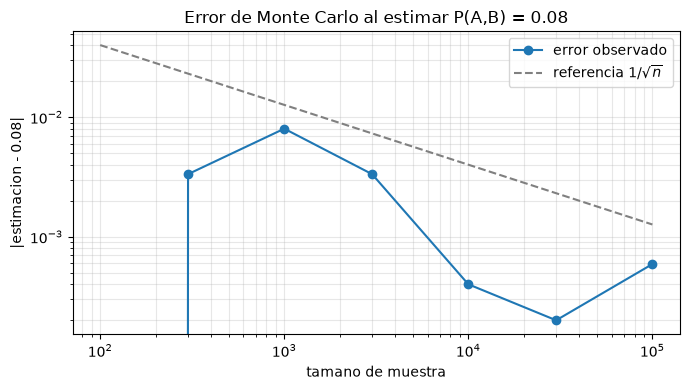

In [54]:
tamanos = [100, 300, 1_000, 3_000, 10_000, 30_000, 100_000]
errores = []
for n in tamanos:
    muestra = muestrear(modelo_factorizado(p_A, p_B_dado_A, p_B_dado_noA), n=n)
    errores.append(abs(p(muestra, {"A": 1, "B": 1})[0] - 0.08))

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(tamanos, errores, "o-", label="error observado")
ax.loglog(tamanos, [0.4 / np.sqrt(n) for n in tamanos], "--",
          color="gray", label=r"referencia $1/\sqrt{n}$")
ax.set_xlabel("tamano de muestra"); ax.set_ylabel("|estimacion - 0.08|")
ax.set_title("Error de Monte Carlo al estimar P(A,B) = 0.08")
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

---
# 2. Independencia condicional en grafos

Todo DAG se descompone en tres estructuras básicas. Saber cuál es cuál es la
destreza central de esta unidad:

| Estructura | Grafo | Sin condicionar | Condicionando en $C$ |
|---|---|---|---|
| Cadena causal | $A \to C \to B$ | dependientes | **independientes** |
| Causa común | $A \leftarrow C \to B$ | dependientes | **independientes** |
| Efecto común (colisionador) | $A \to C \leftarrow B$ | **independientes** | dependientes |

El colisionador es el caso contraintuitivo, y es exactamente la condición (1)
del criterio de separación del enunciado: un nodo de aristas convergentes
bloquea el camino **salvo** que él o alguno de sus descendientes esté en $Z$.

## 2.1 Cadena causal $A \to C \to B$

Las CPT se declaran como tensores indexables por el valor del padre:
`cpt([0.2, 0.9])[A]` es $P(C=1 \mid A)$, con 0.2 si $A=0$ y 0.9 si $A=1$.

Los valores teóricos salen de la **ley de probabilidad total**. Por ejemplo:

$$P(B=1 \mid A=1) = \sum_c P(B=1 \mid c)\, P(c \mid A=1) = 0.8 \times 0.9 + 0.1 \times 0.1 = 0.73$$

In [55]:
with pm.Model() as m_cadena:
    A = pm.Bernoulli("A", 0.3)
    C = pm.Bernoulli("C", cpt([0.2, 0.9])[A])     # P(C=1|A)
    pm.Bernoulli("B", cpt([0.1, 0.8])[C])         # P(B=1|C)

mc_cadena = muestrear(m_cadena, n=100_000)
aristas_cadena = [("A", "C"), ("C", "B")]

# Valores teoricos por ley de probabilidad total
teo_C = 0.3 * 0.9 + 0.7 * 0.2                      # P(C=1)
teo_B = teo_C * 0.8 + (1 - teo_C) * 0.1            # P(B=1)

comparar("P(C=1)",     teo_C, p(mc_cadena, {"C": 1}))
comparar("P(B=1)",     teo_B, p(mc_cadena, {"B": 1}))
comparar("P(B=1|A=1)", 0.9 * 0.8 + 0.1 * 0.1, p(mc_cadena, {"B": 1}, {"A": 1}))
comparar("P(B=1|A=0)", 0.2 * 0.8 + 0.8 * 0.1, p(mc_cadena, {"B": 1}, {"A": 0}))

print("\nAl condicionar en C, el valor de A deja de importar (teoria: 0.8):")
comparar("P(B=1|C=1,A=1)", 0.8, p(mc_cadena, {"B": 1}, {"C": 1, "A": 1}))
comparar("P(B=1|C=1,A=0)", 0.8, p(mc_cadena, {"B": 1}, {"C": 1, "A": 0}))

print()
for Z in ([], ["C"]):
    indep, z = independencia_mc(mc_cadena, "A", "B", Z)
    cond = " | C" if Z else "    "
    print(f"  A _|_ B{cond} -> {str(indep):5s} (z = {z:5.1f})   "
          f"d-separados: {d_separado(aristas_cadena, 'A', 'B', Z)}")

Sampling: [A, B, C]


[OK      ] P(C=1)                     teoria  0.4100   MC  0.4096 +/- 0.0031   n=100000   z=  0.3
[OK      ] P(B=1)                     teoria  0.3870   MC  0.3879 +/- 0.0031   n=100000   z=  0.6
[OK      ] P(B=1|A=1)                 teoria  0.7300   MC  0.7308 +/- 0.0051   n= 29990   z=  0.3
[OK      ] P(B=1|A=0)                 teoria  0.2400   MC  0.2410 +/- 0.0032   n= 70010   z=  0.6

Al condicionar en C, el valor de A deja de importar (teoria: 0.8):
[OK      ] P(B=1|C=1,A=1)             teoria  0.8000   MC  0.8026 +/- 0.0049   n= 26938   z=  1.1
[OK      ] P(B=1|C=1,A=0)             teoria  0.8000   MC  0.8016 +/- 0.0067   n= 14019   z=  0.5

  A _|_ B     -> False (z = 119.4)   d-separados: False
  A _|_ B | C -> True  (z =   0.5)   d-separados: True


---
## Ejercicio 3 — Causa común

Construya el modelo $A \leftarrow C \to B$ con

$$P(C=1) = 0.4, \quad P(A=1 \mid C) = \begin{cases}0.7 & C=1\\ 0.1 & C=0\end{cases},
\quad P(B=1 \mid C) = \begin{cases}0.9 & C=1\\ 0.2 & C=0\end{cases}$$

y verifique que $P(A,B) \neq P(A)P(B)$ pero $P(A,B \mid C) = P(A \mid C)P(B \mid C)$.

**Ojo con el orden de declaración**: en PyMC un nodo sólo puede usar variables
ya definidas, así que $C$ va primero.

In [40]:
with pm.Model() as m_causa:
    # TODO: declare C, luego A y B como hijos de C
    C = pm.Bernoulli("C", 0.5)                  # TODO: P(C=1) = 0.4
    A = pm.Bernoulli("A", 0.5)                  # TODO: use cpt([...])[C]
    B = pm.Bernoulli("B", 0.5)                  # TODO: use cpt([...])[C]

mc_causa = muestrear(m_causa, n=100_000)
aristas_causa = [("C", "A"), ("C", "B")]        # TODO: revise si es correcto

Sampling: [A, B, C]


In [ ]:
# Valores teoricos por ley de probabilidad total
teo_A = 0.4 * 0.7 + 0.6 * 0.1                     # P(A=1)  = 0.34
teo_B = 0.4 * 0.9 + 0.6 * 0.2                     # P(B=1)  = 0.48
teo_AB = 0.4 * 0.7 * 0.9 + 0.6 * 0.1 * 0.2        # P(A,B)  = 0.264

comparar("P(C=1)",     0.40, p(mc_causa, {"C": 1}))
comparar("P(A=1|C=1)", 0.70, p(mc_causa, {"A": 1}, {"C": 1}))
comparar("P(B=1|C=0)", 0.20, p(mc_causa, {"B": 1}, {"C": 0}))
comparar("P(A=1)",   teo_A,  p(mc_causa, {"A": 1}))
comparar("P(A,B)",   teo_AB, p(mc_causa, {"A": 1, "B": 1}))

print(f"\nP(A)P(B) = {teo_A * teo_B:.4f}, pero P(A,B) = {teo_AB:.4f}: dependientes.")
print("Condicionando en C la factorizacion se restablece:")
comparar("P(A,B|C=1)", 0.7 * 0.9, p(mc_causa, {"A": 1, "B": 1}, {"C": 1}))
comparar("P(A,B|C=0)", 0.1 * 0.2, p(mc_causa, {"A": 1, "B": 1}, {"C": 0}))

print()
for Z in ([], ["C"]):
    indep, z = independencia_mc(mc_causa, "A", "B", Z)
    cond = " | C" if Z else "    "
    print(f"  A _|_ B{cond} -> {str(indep):5s} (z = {z:5.1f})   "
          f"d-separados: {d_separado(aristas_causa, 'A', 'B', Z)}")

print()
check("A y B dependientes", not independencia_mc(mc_causa, "A", "B")[0])
check("A y B independientes dado C", independencia_mc(mc_causa, "A", "B", ["C"])[0])

---
## 2.3 El error espejo: ajustar por un mediador

La sección anterior deja una moraleja peligrosa si se lee a medias: «ante una
asociación sospechosa, controle por la otra variable». Este ejemplo muestra el
caso opuesto, donde controlar es exactamente lo que **destruye** la respuesta.

Una cadena de tiendas registra tres cosas cada día: si la jornada fue **húmeda**,
si **llovió** y si hubo **venta alta de paraguas**. El mecanismo no tiene
misterio: el aire húmedo precipita, y la lluvia manda a la gente a comprar
paraguas.

$$\texttt{Humedad} \to \texttt{Lluvia} \to \texttt{Paraguas}$$

```
   Humedad ──► Lluvia ──► Paraguas
```

Es una **cadena causal** (sección 2.1), no una causa común. La humedad sí causa
las ventas: todo su efecto viaja por la lluvia, que es el **mediador**. Ésta es
la parametrización:

| CPT | Valor |
|---|---|
| $P(\texttt{Humedad}=1)$ | 0.5 |
| $P(\texttt{Lluvia}=1 \mid \texttt{Humedad})$ | 0.7 si húmedo, 0.1 si no |
| $P(\texttt{Paraguas}=1 \mid \texttt{Lluvia})$ | 0.9 si llueve, 0.2 si no |

No hay arista `Humedad -> Paraguas`: con la lluvia ya determinada, el bochorno
no vende un solo paraguas más.

In [5]:
with pm.Model() as m_paraguas:
    Humedad = pm.Bernoulli("Humedad", 0.5)
    Lluvia = pm.Bernoulli("Lluvia", cpt([0.1, 0.7])[Humedad])
    Paraguas = pm.Bernoulli("Paraguas", cpt([0.2, 0.9])[Lluvia])

mc_par = muestrear(m_paraguas, n=200_000)
aristas_par = [("Humedad", "Lluvia"), ("Lluvia", "Paraguas")]

# Teoria por ley de probabilidad total
teo_lluvia = 0.5 * 0.7 + 0.5 * 0.1                  # P(Lluvia=1) = 0.40
teo_V1 = 0.7 * 0.9 + 0.3 * 0.2                      # P(V=1|H=1)  = 0.69
teo_V0 = 0.1 * 0.9 + 0.9 * 0.2                      # P(V=1|H=0)  = 0.27

comparar("P(Lluvia=1)", teo_lluvia, p(mc_par, {"Lluvia": 1}))
obs_1 = p(mc_par, {"Paraguas": 1}, {"Humedad": 1})
obs_0 = p(mc_par, {"Paraguas": 1}, {"Humedad": 0})
comparar("P(Paraguas=1 | Humedad=1)", teo_V1, obs_1)
comparar("P(Paraguas=1 | Humedad=0)", teo_V0, obs_0)
print(f"\nAsociacion observada: {100 * (obs_1[0] - obs_0[0]):+.1f} puntos "
      f"a favor de los dias humedos.\n")

# Ahora la misma comparacion "controlando por la lluvia", que es el reflejo
# automatico despues de la seccion 2.2.
print(f"{'':22s}{'Humedad=1':>11s}{'Humedad=0':>11s}{'diferencia':>15s}")
print("-" * 59)
for ll, etiqueta in [(1, "dias con lluvia"), (0, "dias sin lluvia")]:
    v1 = p(mc_par, {"Paraguas": 1}, {"Humedad": 1, "Lluvia": ll})[0]
    v0 = p(mc_par, {"Paraguas": 1}, {"Humedad": 0, "Lluvia": ll})[0]
    print(f"{etiqueta:22s}{v1:11.3f}{v0:11.3f}{100 * (v1 - v0):+12.1f} pp")
print(f"{'todos los dias':22s}{obs_1[0]:11.3f}{obs_0[0]:11.3f}"
      f"{100 * (obs_1[0] - obs_0[0]):+12.1f} pp")

Sampling: [Humedad, Lluvia, Paraguas]


[OK      ] P(Lluvia=1)                teoria  0.4000   MC  0.4018 +/- 0.0022   n=200000   z=  1.6
[OK      ] P(Paraguas=1 | Humedad=1)  teoria  0.6900   MC  0.6931 +/- 0.0029   n=100110   z=  2.1
[OK      ] P(Paraguas=1 | Humedad=0)  teoria  0.2700   MC  0.2698 +/- 0.0028   n= 99890   z=  0.2

Asociacion observada: +42.3 puntos a favor de los dias humedos.

                        Humedad=1  Humedad=0     diferencia
-----------------------------------------------------------
dias con lluvia             0.902      0.901        +0.1 pp
dias sin lluvia             0.200      0.199        +0.1 pp
todos los dias              0.693      0.270       +42.3 pp


Dentro de cada estrato de lluvia la humedad no mueve nada — la diferencia es
cero salvo ruido de muestreo — y sin embargo al juntar todos los días aparecen
42 puntos. **La firma estadística es idéntica a la de la sección 2.2**: una
asociación marginal fuerte que se desvanece al condicionar en la tercera
variable. Los datos observacionales no distinguen

$$\texttt{Humedad} \to \texttt{Lluvia} \to \texttt{Paraguas}
\qquad\text{de}\qquad
\texttt{Humedad} \leftarrow \texttt{Lluvia} \to \texttt{Paraguas}$$

porque ambos grafos implican la misma independencia condicional. Lo que sí las
distingue es la **dirección de las flechas**, y ésa no está en los datos: viene
del conocimiento del dominio. Aquí sabemos que la humedad precede a la lluvia, y
eso cambia por completo la conclusión.

El criterio de puerta trasera lo dice sin ambigüedad. Para estimar el efecto de
`Humedad` sobre `Paraguas` hay que bloquear los caminos que **entran** a
`Humedad`, y no hay ninguno: `Humedad` no tiene padres, así que el conjunto de
ajuste correcto es el **vacío**. El criterio además prohíbe explícitamente
condicionar en descendientes del tratamiento, y `Lluvia` es descendiente de
`Humedad`. Por lo tanto

$$P(\texttt{Paraguas}=1 \mid do(\texttt{Humedad}=h))
= P(\texttt{Paraguas}=1 \mid \texttt{Humedad}=h)$$

sin corregir nada. La asociación cruda **ya era** el efecto causal.

In [6]:
# Tres cantidades sobre los mismos datos: la asociacion cruda, el "ajuste"
# por Lluvia y la intervencion real.
P_LLUVIA = np.array([1 - teo_lluvia, teo_lluvia])   # P(Lluvia=0), P(Lluvia=1)
P_PARAGUAS = np.array([0.2, 0.9])                   # P(V=1 | Lluvia)


def ajuste_por_lluvia(h):
    # Lo que sale de tratar el mediador como si fuera un confusor:
    # sum_ll P(V=1 | h, ll) P(ll).  Como V _|_ H | Lluvia, el resultado
    # no depende de h en absoluto.
    return float(sum(p(mc_par, {"Paraguas": 1}, {"Humedad": h, "Lluvia": ll})[0]
                     * P_LLUVIA[ll] for ll in (0, 1)))


print(f"{'':16s}{'observacional':>15s}{'ajustado x Lluvia':>19s}{'do() pm.do':>13s}")
print("-" * 63)
intervenido = {}
for h in (1, 0):
    mc_do = muestrear(pm.do(m_paraguas, {"Humedad": h}), n=200_000)
    intervenido[h] = mc_do.Paraguas.mean()
    print(f"{'Humedad = ' + str(h):16s}{p(mc_par, {'Paraguas': 1}, {'Humedad': h})[0]:15.3f}"
          f"{ajuste_por_lluvia(h):19.3f}{intervenido[h]:13.3f}")
    comparar(f"  do(Humedad={h})", teo_V1 if h else teo_V0, p(mc_do, {"Paraguas": 1}))

asociacion = obs_1[0] - obs_0[0]
ajustado = ajuste_por_lluvia(1) - ajuste_por_lluvia(0)
efecto = intervenido[1] - intervenido[0]
print(f"\n{'Asociacion   P(V|H=1)  - P(V|H=0)':<36s}= {100 * asociacion:+6.1f} pp")
print(f"{'Ajustado x Lluvia (mediador)':<36s}= {100 * ajustado:+6.1f} pp")
print(f"{'Efecto       P(V|do 1) - P(V|do 0)':<36s}= {100 * efecto:+6.1f} pp")
print(f"{'Sesgo de sobreajuste':<36s}= {100 * (ajustado - efecto):+6.1f} pp")

check("la asociacion cruda ya es el efecto causal",
      abs(asociacion - efecto) < 0.01)
check("ajustar por el mediador borra el efecto", abs(ajustado) < 0.01)

Sampling: [Lluvia, Paraguas]


                  observacional  ajustado x Lluvia   do() pm.do
---------------------------------------------------------------


Sampling: [Lluvia, Paraguas]


Humedad = 1               0.693              0.481        0.691
[OK      ]   do(Humedad=1)            teoria  0.6900   MC  0.6908 +/- 0.0021   n=200000   z=  0.8
Humedad = 0               0.270              0.480        0.269
[OK      ]   do(Humedad=0)            teoria  0.2700   MC  0.2693 +/- 0.0020   n=200000   z=  0.7

Asociacion   P(V|H=1)  - P(V|H=0)   =  +42.3 pp
Ajustado x Lluvia (mediador)        =   +0.1 pp
Efecto       P(V|do 1) - P(V|do 0)  =  +42.1 pp
Sesgo de sobreajuste                =  -42.1 pp
[OK      ] la asociacion cruda ya es el efecto causal
[OK      ] ajustar por el mediador borra el efecto


True

In [ ]:
# El criterio grafico marca las dos razones por las que Lluvia no va en el
# conjunto de ajuste: no bloquea ninguna puerta trasera (no hay), y es
# descendiente del tratamiento.
g_par = nx.DiGraph(aristas_par)
padres_humedad = list(g_par.predecessors("Humedad"))
descendientes = nx.descendants(g_par, "Humedad")

print(f"Padres de Humedad          : {padres_humedad}  -> no hay puerta trasera")
print(f"Descendientes de Humedad   : {sorted(descendientes)}")
print(f"Humedad _|_ Paraguas       : "
      f"{d_separado(aristas_par, 'Humedad', 'Paraguas')}")
print(f"Humedad _|_ Paraguas | Lluvia: "
      f"{d_separado(aristas_par, 'Humedad', 'Paraguas', ['Lluvia'])}")

print()
check("el conjunto de ajuste correcto es el vacio", padres_humedad == [])
check("Lluvia es descendiente de Humedad: prohibido ajustar por ella",
      "Lluvia" in descendientes)
check("la muestra confirma la independencia condicional",
      independencia_mc(mc_par, "Humedad", "Paraguas", ["Lluvia"])[0])

# La misma firma en la causa comun del Ejercicio 3: los datos no las distinguen.
print("\nMisma firma de independencias en los dos grafos:")
print(f"  cadena      A _|_ B: {d_separado(aristas_par, 'Humedad', 'Paraguas')}"
      f"   A _|_ B | C: {d_separado(aristas_par, 'Humedad', 'Paraguas', ['Lluvia'])}")
print(f"  causa comun A _|_ B: {d_separado(aristas_causa, 'A', 'B')}"
      f"   A _|_ B | C: {d_separado(aristas_causa, 'A', 'B', ['C'])}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Izquierda: dentro de cada estrato de lluvia el efecto desaparece.
grupos = [("sin lluvia", {"Lluvia": 0}), ("con lluvia", {"Lluvia": 1}),
          ("todos los dias", {})]
x = np.arange(len(grupos))
alturas = {h: [p(mc_par, {"Paraguas": 1}, {**cond, "Humedad": h})[0]
               for _, cond in grupos] for h in (0, 1)}
axes[0].bar(x - 0.18, alturas[0], 0.35, label="Humedad = 0", color="#4c9be8")
axes[0].bar(x + 0.18, alturas[1], 0.35, label="Humedad = 1", color="#e8834c")
axes[0].set_xticks(x); axes[0].set_xticklabels([g for g, _ in grupos])
axes[0].set_ylabel("P(Paraguas = 1)")
axes[0].set_title("Condicionar en el mediador borra un efecto real")
axes[0].legend(); axes[0].grid(alpha=0.3, axis="y")

# Derecha: las tres cantidades, una al lado de la otra.
etiquetas = ["asociacion\nP(V|H)", "ajustado x Lluvia\n(mediador)",
             "efecto causal\nP(V|do(H))"]
valores = [100 * asociacion, 100 * ajustado, 100 * efecto]
axes[1].bar(etiquetas, valores, color=["#55a868", "#c44e52", "#55a868"])
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_ylabel("diferencia H=1 vs H=0 (puntos porcentuales)")
axes[1].set_title(f"Sesgo de sobreajuste: {100 * (ajustado - efecto):+.1f} pp")
axes[1].grid(alpha=0.3, axis="y")
for i, v in enumerate(valores):
    axes[1].text(i, v + 1.5, f"{v:+.1f} pp", ha="center")

plt.tight_layout(); plt.show()

> **Lo que hay que retener.** El ajuste por `Lluvia` no calcula mal el efecto
> total: calcula **bien otra cosa**. Los 0,0 puntos son el *efecto directo
> controlado* — cuánto vendería más un día húmedo si la lluvia se mantuviera
> fija por decreto — y en esta cadena vale cero por construcción, porque no hay
> arista `Humedad -> Paraguas`. El error no está en la aritmética sino en
> reportar esa cantidad como «el efecto de la humedad».
>
> De ahí la regla práctica: **el conjunto de ajuste se elige con el grafo, no
> con los datos**. Ninguna prueba estadística separa este caso del de la sección
> 2.2, porque ambos producen la misma tabla; la diferencia está en si la tercera
> variable es un **confusor** (causa del tratamiento: hay que ajustar) o un
> **mediador o descendiente** del tratamiento (no hay que ajustar).
>
> En la sección 5 el conjunto $\{\texttt{Anio}, \texttt{Sexo}\}$ pasa las dos
> pruebas: bloquea las puertas traseras de `Dep` **y** ninguno de los dos es
> descendiente de `Dep`. Por eso ahí ajustar es lo correcto, y aquí no.

---
## 2.4 Datos continuos y un mediador no observado

Los ejemplos anteriores eran binarios porque así se leen las tablas de
probabilidad. La lógica causal, sin embargo, no depende de eso. Aquí repetimos
la cadena con variables **continuas** y con la complicación que aparece siempre
en la práctica: **la lluvia no se mide**.

| Variable | Unidad |
|---|---|
| `Humedad` | humedad relativa (%) |
| `Lluvia` | precipitación del día (mm) — **no observada** |
| `Ventas` | paraguas vendidos |

El mecanismo es el mismo de la sección 2.3, ahora escrito como un sistema de
ecuaciones estructurales lineales:

$$\begin{aligned}
\texttt{Humedad} &\sim \mathcal{N}(70,\ 8^2)\\
\texttt{Lluvia} &= -8 + 0.25\,\texttt{Humedad} + \varepsilon_L,
&\varepsilon_L &\sim \mathcal{N}(0,\ 1.2^2)\\
\texttt{Ventas} &= 20 + 6\,\texttt{Lluvia} + \varepsilon_V,
&\varepsilon_V &\sim \mathcal{N}(0,\ 8^2)
\end{aligned}$$

Cada coeficiente es un **efecto directo**, y el efecto total de la humedad sobre
las ventas es el producto a lo largo del camino:

$$\frac{\partial\,\mathbb{E}[\texttt{Ventas}]}{\partial\,\texttt{Humedad}}
= 0.25 \times 6 = 1.5 \text{ paraguas por punto de humedad}$$

Ése es el número que hay que recuperar viendo **sólo** `Humedad` y `Ventas`.

In [31]:
def muestrear_cont(modelo, n=2_000, semilla=SEMILLA):
    # Igual que muestrear(), pero sin forzar booleanos: aqui todo es continuo.
    with modelo:
        previa = pm.sample_prior_predictive(draws=n, random_seed=semilla)
    nombres = ([v.name for v in modelo.free_RVs]
               + [d.name for d in modelo.deterministics])
    return pd.DataFrame({v: previa.prior[v].values.reshape(-1) for v in nombres})


# El modelo generativo verdadero: el mismo DAG de 2.3, ahora con Normales.
A0, A1, SIGMA_L = -8.0, 0.25, 1.2      # Lluvia  = A0 + A1 * Humedad + ruido
B0, B1, SIGMA_V = 20.0, 6.0, 8.0       # Ventas  = B0 + B1 * Lluvia  + ruido
EFECTO_TOTAL = A1 * B1                 # 1.5 paraguas por punto de humedad

with pm.Model() as m_clima:
    Humedad = pm.Normal("Humedad", 70.0, 8.0)
    Lluvia = pm.Normal("Lluvia", A0 + A1 * Humedad, SIGMA_L)
    Ventas = pm.Normal("Ventas", B0 + B1 * Lluvia, SIGMA_V)

clima = muestrear_cont(m_clima, n=2_000)
print(clima.describe().round(2).to_string())
print("\nCorrelaciones:")
print(clima.corr().round(3).to_string())

# A partir de aqui la lluvia deja de existir para nosotros.
observado = clima[["Humedad", "Ventas"]].copy()
print(f"\nDatos disponibles: {list(observado.columns)}   n = {len(observado)}")

Sampling: [Humedad, Lluvia, Ventas]


       Humedad   Lluvia   Ventas
count  2000.00  2000.00  2000.00
mean     70.02     9.52    76.74
std       7.94     2.34    16.23
min      37.26     0.09     8.46
25%      64.88     7.92    66.00
50%      69.84     9.61    76.51
75%      75.19    11.08    87.44
max      93.44    17.29   134.23

Correlaciones:
         Humedad  Lluvia  Ventas
Humedad    1.000   0.852   0.740
Lluvia     0.852   1.000   0.872
Ventas     0.740   0.872   1.000

Datos disponibles: ['Humedad', 'Ventas']   n = 2000


In [32]:
clima.head()

,Humedad,Lluvia,Ventas
0,73.346640,11.842053,77.857127
1,74.844609,11.438700,99.880190
2,70.230303,7.949363,73.483945
3,61.326032,6.048543,49.658734
4,81.713768,14.040609,108.114604


In [33]:
import statsmodels.api as sm

X=sm.add_constant(observado["Humedad"])
modelo_ols = sm.OLS(observado["Ventas"], X).fit()
print(modelo_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                 Ventas   R-squared:                       0.547
Model:                            OLS   Adj. R-squared:                  0.547
Method:                 Least Squares   F-statistic:                     2413.
Date:                Tue, 01 Sep 2026   Prob (F-statistic):               0.00
Time:                        11:53:07   Log-Likelihood:                -7619.2
No. Observations:                2000   AIC:                         1.524e+04
Df Residuals:                    1998   BIC:                         1.525e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -29.1638      2.170    -13.440      0.0

In [35]:
X_causal = sm.add_constant(clima[['Lluvia', 'Humedad']])
modelo_causal = sm.OLS(clima['Ventas'], X_causal).fit()
print(modelo_causal.summary())

                            OLS Regression Results                            
Dep. Variable:                 Ventas   R-squared:                       0.760
Model:                            OLS   Adj. R-squared:                  0.760
Method:                 Least Squares   F-statistic:                     3158.
Date:                Tue, 01 Sep 2026   Prob (F-statistic):               0.00
Time:                        11:53:14   Log-Likelihood:                -6984.9
No. Observations:                2000   AIC:                         1.398e+04
Df Residuals:                    1997   BIC:                         1.399e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         20.1358      1.968     10.233      0.0

Como el modelo generativo está a la vista, podemos calcular la respuesta
correcta interviniendo, igual que en la sección 2.3: `pm.do` borra la ecuación
de `Humedad` y la fija en un valor. Subir la humedad de 70 % a 80 % debería
mover las ventas en $10 \times 1.5 = 15$ paraguas.

Esto es lo que en un problema real **no** se puede hacer, y sirve sólo para
tener contra qué contrastar lo que estimemos después.

In [37]:
for h in (70.0, 80.0):
    inter = muestrear_cont(pm.do(m_clima, {"Humedad": h}), n=20_000)
    print(f"E[Ventas | do(Humedad = {h:.0f})] = {inter.Ventas.mean():6.2f}   "
          f"(teoria {B0 + B1 * (A0 + A1 * h):6.2f})")

oraculo = 10 * EFECTO_TOTAL
print(f"\nEfecto de subir la humedad 10 puntos: {oraculo:.1f} paraguas.")



Sampling: [Lluvia, Ventas]


Sampling: [Lluvia, Ventas]


E[Ventas | do(Humedad = 70)] =  76.92   (teoria  77.00)
E[Ventas | do(Humedad = 80)] =  91.92   (teoria  92.00)

Efecto de subir la humedad 10 puntos: 15.0 paraguas.


In [42]:
# Y el equivalente continuo de la seccion 2.3: dos regresiones por minimos
# cuadrados, una con la lluvia y otra sin ella.
unos = np.ones(len(clima))
beta_sin = modelo_ols.params
beta_con = modelo_causal.params

print(f"\nOLS  Ventas ~ Humedad           -> coef. Humedad = {beta_sin['Humedad']:6.3f}")
print(f"OLS  Ventas ~ Humedad + Lluvia  -> coef. Humedad = {beta_con['Humedad']:6.3f}"
      f"   coef. Lluvia = {beta_con['Lluvia']:6.3f}")

check("la regresion simple recupera el efecto total",
      abs(beta_sin['Humedad'] - EFECTO_TOTAL) < 0.05)
check("controlar por la lluvia lo borra (efecto directo = 0)",
      abs(beta_con['Humedad']) < 0.05)


OLS  Ventas ~ Humedad           -> coef. Humedad =  1.512
OLS  Ventas ~ Humedad + Lluvia  -> coef. Humedad = -0.023   coef. Lluvia =  6.117
[OK      ] la regresion simple recupera el efecto total
[OK      ] controlar por la lluvia lo borra (efecto directo = 0)


True

> La regresión que **omite** la lluvia da la respuesta correcta, y la que la
> **incluye** da cero. Es exactamente la tabla de la sección 2.3, sin
> discretizar nada: el mediador no va en el modelo si lo que se busca es el
> efecto total.

### El modelo gráfico sobre lo observable

Con `Lluvia` fuera del alcance, el grafo que podemos escribir tiene dos nodos:

```
   Humedad ──► Ventas          (Lluvia queda dentro de la flecha)
```

Esto **no** es una simplificación gratuita: es la consecuencia de que el efecto
total sea identificable. `Humedad` no tiene padres, así que no hay puerta
trasera que bloquear, el conjunto de ajuste es el vacío y

$$\mathbb{E}[\texttt{Ventas} \mid do(\texttt{Humedad}=h)]
= \mathbb{E}[\texttt{Ventas} \mid \texttt{Humedad}=h] = \gamma_0 + \gamma_1 h$$

con $\gamma_1 = a_1 b_1$. La lluvia sobrevive en dos lugares: en la pendiente,
que es el producto de los dos efectos directos, y en la varianza residual, que
ahora mezcla $\varepsilon_V$ con la parte de $\varepsilon_L$ que se propaga.

Estimamos $\gamma_1$ con PyMC, esta vez con MCMC y no por muestreo directo,
porque hay parámetros que aprender de los datos.

In [44]:
import arviz as az

hum_c = observado.Humedad.values - observado.Humedad.values.mean()   # centrado

with pm.Model() as m_observable:
    gamma_0 = pm.Normal("gamma_0", 75.0, 25.0)
    gamma_1 = pm.Normal("efecto_total", 0.0, 5.0)     # lo que queremos estimar
    sigma = pm.HalfNormal("sigma", 20.0)
    pm.Normal("Ventas", gamma_0 + gamma_1 * hum_c, sigma,
              observed=observado.Ventas.values)
    # init="adapt_diag": el jitter por defecto arranca lejos con estas priores
    # anchas y ensucia la salida con avisos de overflow. La posterior es la misma.
    post_obs = pm.sample(1_000, tune=1_000, chains=4, random_seed=SEMILLA,
                         init="adapt_diag", progressbar=False)


def resumen_post(nombre, draws, verdad=None):
    # Resumen de una posterior en el formato de comparar(): la marca OK indica
    # que el valor verdadero cae dentro del intervalo de credibilidad del 95 %.
    draws = np.asarray(draws).reshape(-1)
    lo, hi = np.percentile(draws, [2.5, 97.5])
    marca = "        " if verdad is None else (
        "OK      " if lo <= verdad <= hi else "REVISAR ")
    verdad_txt = f"verdad {verdad:7.3f}   " if verdad is not None else " " * 18
    print(f"[{marca}] {nombre:<24s} {verdad_txt}post {draws.mean():7.3f} "
          f"+/- {draws.std():.3f}   IC95 [{lo:6.3f}, {hi:6.3f}]")
    return draws


gamma_draws = resumen_post("efecto total (paraguas/%)",
                           post_obs.posterior["efecto_total"], EFECTO_TOTAL)
resumen_post("subir 10 puntos", 10 * gamma_draws, oraculo)
print(f"\nr-hat efecto_total: "
      f"{float(az.rhat(post_obs, var_names=['efecto_total'])['efecto_total']):.4f}")

Initializing NUTS using adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [gamma_0, efecto_total, sigma]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


[OK      ] efecto total (paraguas/%) verdad   1.500   post   1.513 +/- 0.031   IC95 [ 1.452,  1.571]
[OK      ] subir 10 puntos          verdad  15.000   post  15.127 +/- 0.306   IC95 [14.523, 15.712]

r-hat efecto_total: 1.0009


### Lo que sí se pierde: la descomposición

El efecto total se recupera, pero los dos efectos directos **no**. Sin observar
la lluvia, los datos sólo contienen el producto $a_1 b_1 = 1.5$, y hay
infinitas maneras de repartirlo: que la humedad suba la lluvia 0,25 mm por punto
y cada mm venda 6 paraguas, o que la suba 0,5 mm y cada mm venda 3, produce
exactamente la misma nube de puntos.

Para verlo, declaramos el modelo gráfico **con la lluvia como variable latente**
—un nodo `pm.Normal` sin `observed`, que el muestreador tiene que imputar— y lo
ajustamos dos veces, suponiendo cada vez un valor distinto de $b_1$ traído
desde afuera. Los datos no eligen entre los dos supuestos; ambos ajustan igual
de bien y ambos dan el mismo efecto total.

> Al correr esta celda PyMC advertirá que el r-hat es alto «para algunos
> parámetros». Son las 400 variables latentes `Lluvia`, cada una determinada por
> un solo dato; los parámetros que importan tienen r-hat ≈ 1,00, y la celda los
> imprime para que se vea.

In [45]:
N_SUB = 400          # basta con 400 dias: cada uno agrega una latente que muestrear
h_sub = hum_c[:N_SUB]
v_sub = observado.Ventas.values[:N_SUB]


def ajustar_con_latente(b1_supuesto):
    # El DAG completo Humedad -> Lluvia -> Ventas, con Lluvia SIN observar.
    with pm.Model() as m:
        a0 = pm.Normal("a0", 9.5, 10.0)
        a1 = pm.Normal("a1", 0.0, 2.0)
        Lluvia_lat = pm.Normal("Lluvia", a0 + a1 * h_sub, SIGMA_L, shape=N_SUB)
        sigma_v = pm.HalfNormal("sigma_V", 20.0)
        pm.Normal("Ventas", b1_supuesto * Lluvia_lat, sigma_v, observed=v_sub)
        pm.Deterministic("efecto_total", a1 * b1_supuesto)
        idata = pm.sample(500, tune=500, chains=2, target_accept=0.9,
                          random_seed=SEMILLA, progressbar=False)
    return idata


latentes = {}
for b1_supuesto in (6.0, 3.0):
    idata = latentes[b1_supuesto] = ajustar_con_latente(b1_supuesto)
    print(f"\n--- suponiendo b1 = {b1_supuesto} paraguas por mm ---")
    resumen_post("a1 (mm por punto)", idata.posterior["a1"], EFECTO_TOTAL / b1_supuesto)
    resumen_post("efecto total", idata.posterior["efecto_total"], EFECTO_TOTAL)
    rhat = az.rhat(idata, var_names=["a1", "sigma_V", "efecto_total"])
    print("    r-hat: " + "  ".join(f"{k}={float(v):.3f}" for k, v in rhat.items()))

print()
check("el efecto total no depende del supuesto sobre b1",
      abs(latentes[6.0].posterior["efecto_total"].values.mean()
          - latentes[3.0].posterior["efecto_total"].values.mean()) < 0.05)
check("a1 si depende del supuesto: no esta identificado",
      abs(latentes[6.0].posterior["a1"].values.mean()
          - latentes[3.0].posterior["a1"].values.mean()) > 0.1)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [a0, a1, Lluvia, sigma_V]
Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 3 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
Initializing NUTS using jitter+adapt_diag...



--- suponiendo b1 = 6.0 paraguas por mm ---
[OK      ] a1 (mm por punto)        verdad   0.250   post   0.259 +/- 0.012   IC95 [ 0.235,  0.282]
[OK      ] efecto total             verdad   1.500   post   1.556 +/- 0.071   IC95 [ 1.411,  1.693]
    r-hat: a1=1.007  sigma_V=1.004  efecto_total=1.007


Multiprocess sampling (2 chains in 2 jobs)
NUTS: [a0, a1, Lluvia, sigma_V]
Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 5 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details



--- suponiendo b1 = 3.0 paraguas por mm ---
[OK      ] a1 (mm por punto)        verdad   0.500   post   0.520 +/- 0.025   IC95 [ 0.474,  0.567]
[OK      ] efecto total             verdad   1.500   post   1.559 +/- 0.074   IC95 [ 1.423,  1.702]
    r-hat: a1=1.006  sigma_V=1.006  efecto_total=1.006

[OK      ] el efecto total no depende del supuesto sobre b1
[OK      ] a1 si depende del supuesto: no esta identificado


True

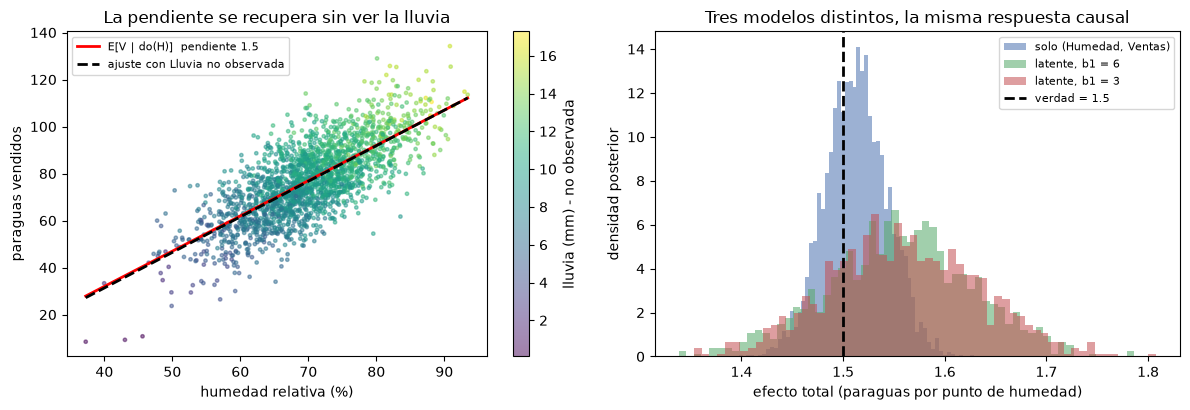

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# Izquierda: los datos observables, coloreados por la variable que no vemos.
sc = axes[0].scatter(clima.Humedad, clima.Ventas, c=clima.Lluvia, s=6,
                     alpha=0.5, cmap="viridis")
rejilla = np.linspace(clima.Humedad.min(), clima.Humedad.max(), 50)
axes[0].plot(rejilla, B0 + B1 * (A0 + A1 * rejilla), "r-", lw=2,
             label=f"E[V | do(H)]  pendiente {EFECTO_TOTAL}")
axes[0].plot(rejilla, gamma_draws.mean() * (rejilla - clima.Humedad.mean())
             + post_obs.posterior["gamma_0"].values.mean(), "k--", lw=2,
             label="ajuste con Lluvia no observada")
fig.colorbar(sc, ax=axes[0], label="lluvia (mm) - no observada")
axes[0].set_xlabel("humedad relativa (%)"); axes[0].set_ylabel("paraguas vendidos")
axes[0].set_title("La pendiente se recupera sin ver la lluvia")
axes[0].legend(fontsize=8, loc="upper left")

# Derecha: las tres posteriores del efecto total, con el valor verdadero.
series = [("solo (Humedad, Ventas)", gamma_draws, "#4c72b0"),
          ("latente, b1 = 6", latentes[6.0].posterior["efecto_total"].values.reshape(-1), "#55a868"),
          ("latente, b1 = 3", latentes[3.0].posterior["efecto_total"].values.reshape(-1), "#c44e52")]
for etiqueta, draws, color in series:
    axes[1].hist(draws, bins=60, density=True, alpha=0.55, label=etiqueta, color=color)
axes[1].axvline(EFECTO_TOTAL, color="black", ls="--", lw=2,
                label=f"verdad = {EFECTO_TOTAL}")
axes[1].set_xlabel("efecto total (paraguas por punto de humedad)")
axes[1].set_ylabel("densidad posterior")
axes[1].set_title("Tres modelos distintos, la misma respuesta causal")
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

> **Lo que hay que retener.** Que una variable del mecanismo sea inobservable no
> arruina la pregunta causal: arruina **algunas** preguntas causales. Aquí el
> efecto total de la humedad sobre las ventas queda perfectamente identificado
> —los tres ajustes coinciden en 1,5 paraguas por punto, con el verdadero
> dentro del intervalo del 95 %— mientras que la descomposición en «cuánta
> lluvia» y «cuántos paraguas por mm» es indeterminable: cada supuesto sobre
> $b_1$ da un $a_1$ distinto y ninguno ajusta mejor que el otro.
>
> Conviene contrastar esto con el caso de la sección 2.2. Allí la variable no
> observada habría sido un **confusor**, y entonces sí no habría nada que hacer:
> sin medir el calor, la asociación humedad–ventas no se puede limpiar. La
> diferencia no está en cuántas variables faltan, sino en **dónde** están en el
> grafo: un mediador faltante deja el efecto total intacto, un confusor faltante
> lo destruye.
>
> Esto también explica una práctica común y equivocada en informes aplicados:
> meter en la regresión «todas las variables disponibles» para controlar por
> ellas. Con `Lluvia` en la tabla, ese reflejo habría producido un coeficiente
> de humedad igual a cero y la conclusión de que la humedad no vende paraguas.

---
## 2.5 ¿Se puede detectar un modelo equivocado?

La sección anterior estimó el efecto **suponiendo** el grafo
`Humedad -> Lluvia -> Ventas`. Cabe la pregunta obvia: si el grafo estuviera
mal, ¿lo dirían los datos? Tomemos la alternativa concreta de convertir las
ventas en un **efecto común**, y agreguemos una tercera candidata para tener el
cuadro completo:

| | Grafo | Historia |
|---|---|---|
| **A** cadena | `Humedad → Lluvia → Ventas` | la humedad precipita, la lluvia vende |
| **B** colisionador | `Humedad → Ventas ← Lluvia` | humedad y lluvia son causas separadas de la venta |
| **C** confusor | `Humedad ← Nubosidad → Ventas` | la humedad no vende nada; ambas cuelgan del mismo cielo |

Los tres son modelos lineales gaussianos y los tres tienen tres variables, pero
sólo dos son observables. La pregunta se parte en dos:

1. ¿Producen los tres la **misma distribución** de `(Humedad, Ventas)`?
2. ¿Dan la **misma respuesta causal**?

Elegimos los coeficientes de **B** y **C** para que la respuesta a (1) sea sí,
exactamente: los tres implican $\texttt{Humedad} \sim \mathcal{N}(70, 8^2)$ y
$\texttt{Ventas} \mid \texttt{Humedad} \sim \mathcal{N}(-28 + 1.5\,\texttt{Humedad},\ 115.84)$.
No es trampa: es lo que hace un ajuste por máxima verosimilitud si le damos
cualquiera de las tres estructuras y los mismos datos.

In [ ]:
# Tres mecanismos distintos, calibrados para que (Humedad, Ventas) sea identica.
with pm.Model() as m_cadena_c:                    # A:  H -> L -> V
    H_a = pm.Normal("Humedad", 70.0, 8.0)
    L_a = pm.Normal("Lluvia", A0 + A1 * H_a, SIGMA_L)
    pm.Normal("Ventas", B0 + B1 * L_a, SIGMA_V)

with pm.Model() as m_colisionador:                # B:  H -> V <- L
    H_b = pm.Normal("Humedad", 70.0, 8.0)
    L_b = pm.Normal("Lluvia", 9.5, np.sqrt(5.44))         # ahora es exogena
    pm.Normal("Ventas", -56.5 + 1.5 * H_b + 3.0 * L_b, np.sqrt(66.88))

with pm.Model() as m_confusor:                    # C:  H <- U -> V
    U_c = pm.Normal("Nubosidad", 0.0, 1.0)
    H_c = pm.Normal("Humedad", 70.0 + 7.0 * U_c, np.sqrt(64.0 - 49.0))
    pm.Normal("Ventas", 77.0 + (96 / 7) * U_c, np.sqrt(259.84 - (96 / 7) ** 2))

CANDIDATOS = [("A cadena", m_cadena_c, "Lluvia"),
              ("B colisionador", m_colisionador, "Lluvia"),
              ("C confusor", m_confusor, "Nubosidad")]

simulados = {nombre: muestrear_cont(m, n=100_000) for nombre, m, _ in CANDIDATOS}

print(f"{'modelo':<16}{'E[H]':>7}{'sd[H]':>7}{'E[V]':>8}{'sd[V]':>7}"
      f"{'cov(H,V)':>10}{'OLS V~H':>9}")
print("-" * 64)
for nombre, _, _ in CANDIDATOS:
    d = simulados[nombre]
    print(f"{nombre:<16}{d.Humedad.mean():7.2f}{d.Humedad.std():7.2f}"
          f"{d.Ventas.mean():8.2f}{d.Ventas.std():7.2f}"
          f"{d.Humedad.cov(d.Ventas):10.2f}"
          f"{np.polyfit(d.Humedad, d.Ventas, 1)[0]:9.3f}")

pendientes = [np.polyfit(d.Humedad, d.Ventas, 1)[0] for d in simulados.values()]
check("los tres son indistinguibles mirando (Humedad, Ventas)",
      max(pendientes) - min(pendientes) < 0.02)

Idénticos hasta el segundo decimal: media, varianza, covarianza y pendiente. Con
`Lluvia` fuera de la tabla, **ningún** procedimiento estadístico puede preferir
uno de los tres, porque los tres asignan la misma verosimilitud a cualquier
conjunto de datos. Ahora la pregunta que importa: ¿coinciden también en la
respuesta causal?

In [ ]:
print(f"{'modelo':<16}{'E[V|do(H=70)]':>15}{'E[V|do(H=80)]':>15}{'efecto de +10':>15}")
print("-" * 61)
efectos = {}
for nombre, m, _ in CANDIDATOS:
    e70 = muestrear_cont(pm.do(m, {"Humedad": 70.0}), n=50_000).Ventas.mean()
    e80 = muestrear_cont(pm.do(m, {"Humedad": 80.0}), n=50_000).Ventas.mean()
    efectos[nombre] = e80 - e70
    print(f"{nombre:<16}{e70:15.2f}{e80:15.2f}{e80 - e70:15.2f}")

check("A y B coinciden en la respuesta causal",
      abs(efectos["A cadena"] - efectos["B colisionador"]) < 0.5)
check("C da una respuesta radicalmente distinta con los mismos datos",
      abs(efectos["C confusor"]) < 0.5)

Aquí está el fondo del asunto. Los tres modelos son **indistinguibles con los
datos observables** y sin embargo dos de ellos dicen que subir la humedad diez
puntos vende 15 paraguas y el tercero dice que no vende ninguno. La misma nube
de puntos sostiene las dos conclusiones; lo único que las separa es el supuesto
sobre el mecanismo. Es la formulación operativa de la regla de Pearl: *sin
causas a la entrada, no hay causas a la salida*.

Note además que el colisionador que propusimos (**B**) resulta **inofensivo**
para esta pregunta: coincide con la cadena en el efecto de `Humedad`. La razón
es que en ambos grafos `Humedad` no tiene padres, así que no hay puerta trasera
y $\mathbb{E}[V \mid do(h)] = \mathbb{E}[V \mid h]$ en los dos. Equivocarse de
grafo importa cuando el error cambia la estructura de puertas traseras, no por
sí mismo.

### Lo que sí es testeable

Si la tercera variable **se mide**, la simetría se rompe, y de una forma muy
concreta: el colisionador es la única de las tres estructuras que implica una
independencia *marginal* entre los extremos. Medimos esto con la **correlación
parcial**, que para variables gaussianas es cero exactamente cuando hay
independencia condicional.

In [ ]:
def corr_parcial(df, X, Y, Z=None):
    # Correlacion entre X e Y quitando la parte lineal de Z. Para gaussianas,
    # es el equivalente continuo de independencia_mc(): cero <=> X _|_ Y | Z.
    r = df.corr()
    if Z is None:
        return float(r.loc[X, Y])
    rxy, rxz, ryz = r.loc[X, Y], r.loc[X, Z], r.loc[Y, Z]
    return float((rxy - rxz * ryz) / np.sqrt((1 - rxz ** 2) * (1 - ryz ** 2)))


print(f"{'modelo':<16}{'r(H, Z)':>10}{'r(H, V)':>10}{'r(H, V | Z)':>14}"
      f"   firma")
print("-" * 66)
firmas = {}
for nombre, _, z in CANDIDATOS:
    d = simulados[nombre]
    r_hz = corr_parcial(d, "Humedad", z)
    r_hv = corr_parcial(d, "Humedad", "Ventas")
    r_hv_z = corr_parcial(d, "Humedad", "Ventas", z)
    firmas[nombre] = (abs(r_hz) < 0.05, abs(r_hv_z) < 0.05)
    marca = ("H _|_ Z" if firmas[nombre][0] else "H no_|_ Z")
    marca += ",  " + ("H _|_ V | Z" if firmas[nombre][1] else "H no_|_ V | Z")
    print(f"{nombre:<16}{r_hz:10.3f}{r_hv:10.3f}{r_hv_z:14.3f}   {marca}")

# El veredicto sobre los datos de la seccion 2.4, donde la lluvia SI se midio.
print(f"\nDatos observados (seccion 2.4):")
print(f"  r(Humedad, Lluvia)          = {corr_parcial(clima, 'Humedad', 'Lluvia'):6.3f}")
print(f"  r(Humedad, Ventas | Lluvia) = "
      f"{corr_parcial(clima, 'Humedad', 'Ventas', 'Lluvia'):6.3f}")

check("los datos REFUTAN el colisionador: exige r(H, Lluvia) = 0",
      abs(corr_parcial(clima, "Humedad", "Lluvia")) > 0.05)
check("los datos NO distinguen la cadena del confusor: misma firma",
      firmas["A cadena"] == firmas["C confusor"])

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# Izquierda: las tres nubes observables, superpuestas.
for (nombre, _, _), color in zip(CANDIDATOS, ["#4c72b0", "#dd8452", "#55a868"]):
    d = simulados[nombre].iloc[:1500]
    axes[0].scatter(d.Humedad, d.Ventas, s=4, alpha=0.25, color=color, label=nombre)
rejilla = np.linspace(45, 95, 20)
axes[0].plot(rejilla, -28 + 1.5 * rejilla, "k-", lw=2, label="misma recta")
axes[0].set_xlabel("humedad relativa (%)"); axes[0].set_ylabel("paraguas vendidos")
axes[0].set_title("Lo observable: una sola nube")
leyenda = axes[0].legend(fontsize=8, loc="upper left")
for h in leyenda.legend_handles[:3]:
    h.set_alpha(1)

# Derecha: la respuesta causal de cada uno.
nombres = [n for n, _, _ in CANDIDATOS]
axes[1].bar(nombres, [efectos[n] for n in nombres],
            color=["#4c72b0", "#dd8452", "#55a868"])
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_ylabel("E[V | do(H=80)] - E[V | do(H=70)]")
axes[1].set_title("Lo no observable: dos respuestas distintas")
axes[1].grid(alpha=0.3, axis="y")
for i, n in enumerate(nombres):
    axes[1].text(i, efectos[n] + 0.4, f"{efectos[n]:.1f}", ha="center")

plt.tight_layout(); plt.show()

> **Respuesta a la pregunta.** Sí y no, y la frontera es precisa.
>
> **Sí**, un modelo equivocado puede detectarse cuando implica una
> independencia condicional que los datos refutan. El colisionador
> `Humedad → Ventas ← Lluvia` exige que humedad y lluvia sean **marginalmente
> independientes**, y en los datos su correlación es 0,85: queda descartado, sin
> ambigüedad. Ésa es la huella que dejan las v-estructuras, y es la razón de que
> los algoritmos de descubrimiento causal (PC, GES) puedan orientar algunas
> aristas y no otras.
>
> **No**, cuando dos grafos pertenecen a la misma **clase de equivalencia de
> Markov** —mismo esqueleto y mismas v-estructuras—. La cadena
> `H → L → V` y el confusor `H ← U → V` tienen exactamente la misma firma
> (`H no⊥ Z`, `H ⊥ V | Z`) y ninguna prueba estadística las separa, ni con
> infinitos datos. Es el mismo punto de la sección 2.3, ahora con el precio a la
> vista: una da 15 paraguas y la otra da 0.
>
> Y hay una condición previa que se olvida fácil: **todo esto exige medir la
> tercera variable**. Con sólo `(Humedad, Ventas)` los tres modelos son
> observacionalmente idénticos y no hay nada que testear. Por eso la fase de
> diseño —qué variables se van a medir— decide más sobre lo que se podrá
> concluir que cualquier técnica de estimación aplicada después.

---
## 2.6 Una puerta trasera de verdad

`m_confusor` era un caso extremo: la humedad no causaba nada y toda la
asociación era espuria. El caso realista tiene las tres cosas a la vez. Le
devolvemos a ese modelo el mecanismo causal —la humedad precipita y la lluvia
vende— y le dejamos la nubosidad como causa común:

$$\begin{aligned}
\texttt{Nubosidad} &\sim \mathcal{N}(0, 1)\\
\texttt{Humedad} &= 70 + 6\,\texttt{Nubosidad} + \varepsilon_H,
&\varepsilon_H &\sim \mathcal{N}(0, 6^2)\\
\texttt{Lluvia} &= -8 + 0.25\,\texttt{Humedad} + \varepsilon_L,
&\varepsilon_L &\sim \mathcal{N}(0, 1.2^2)\\
\texttt{Ventas} &= 20 + 0.5\,\texttt{Humedad} + 6\,\texttt{Lluvia}
+ 12\,\texttt{Nubosidad} + \varepsilon_V,
&\varepsilon_V &\sim \mathcal{N}(0, 8^2)
\end{aligned}$$

```
              Nubosidad
             /         \
            v           v
       Humedad ──► Lluvia ──► Ventas
            └──────────────────►┘
```

Ahora hay **tres** caminos entre `Humedad` y `Ventas`, y hay que distinguirlos
porque no se tratan igual:

| Camino | Tipo | ¿Qué hacer? |
|---|---|---|
| `Humedad → Ventas` | causal directo | dejarlo pasar |
| `Humedad → Lluvia → Ventas` | causal indirecto | dejarlo pasar |
| `Humedad ← Nubosidad → Ventas` | **puerta trasera** | bloquearlo |

Los dos primeros suman el **efecto total**, que por construcción vale
$0.5 + 0.25 \times 6 = 2.0$ paraguas por punto de humedad. El tercero es
contaminación pura. Y hay una segunda pregunta, distinta de la primera: el
**efecto directo**, $0.5$, que es lo que quedaría si la lluvia se mantuviera
fija.

In [ ]:
with pm.Model() as m_puerta_trasera:
    Nubosidad = pm.Normal("Nubosidad", 0.0, 1.0)
    Humedad_pt = pm.Normal("Humedad", 70.0 + 6.0 * Nubosidad, 6.0)
    Lluvia_pt = pm.Normal("Lluvia", -8.0 + 0.25 * Humedad_pt, 1.2)
    pm.Normal("Ventas", 20.0 + 0.5 * Humedad_pt + 6.0 * Lluvia_pt
              + 12.0 * Nubosidad, 8.0)

ARISTAS_PT = [("Nubosidad", "Humedad"), ("Nubosidad", "Ventas"),
              ("Humedad", "Lluvia"), ("Lluvia", "Ventas"), ("Humedad", "Ventas")]

EFECTO_DIRECTO = 0.5
EFECTO_INDIRECTO = 0.25 * 6.0
EFECTO_TOTAL_PT = EFECTO_DIRECTO + EFECTO_INDIRECTO      # 2.0

pt = muestrear_cont(m_puerta_trasera, n=100_000)
print(pt.describe().round(2).to_string())


def bloquea_puerta_trasera(aristas, X, Y, Z=()):
    # Criterio de puerta trasera de Pearl, en sus dos condiciones:
    #   (1) ningun elemento de Z es descendiente de X;
    #   (2) Z d-separa X de Y en el grafo SIN las aristas que salen de X.
    Z = [Z] if isinstance(Z, str) else list(Z)
    if set(Z) & nx.descendants(nx.DiGraph(aristas), X):
        return False
    mutilado = [(u, v) for u, v in aristas if u != X]
    return d_separado(mutilado, X, Y, Z)


print("\nCriterio de puerta trasera para el efecto TOTAL de Humedad:")
for Z in ([], ["Nubosidad"], ["Lluvia"], ["Nubosidad", "Lluvia"]):
    valido = bloquea_puerta_trasera(ARISTAS_PT, "Humedad", "Ventas", Z)
    print(f"  Z = {str(Z):26s} -> {'valido' if valido else 'NO valido'}")

check("{Nubosidad} es un conjunto de ajuste valido",
      bloquea_puerta_trasera(ARISTAS_PT, "Humedad", "Ventas", ["Nubosidad"]))
check("agregar Lluvia lo invalida: es descendiente de Humedad",
      not bloquea_puerta_trasera(ARISTAS_PT, "Humedad", "Ventas",
                                 ["Nubosidad", "Lluvia"]))

El criterio rechaza `{Nubosidad, Lluvia}` aunque contenga al confusor, y ésa es
la parte que cuesta aceptar: **agregar variables puede romper un conjunto de
ajuste que ya era válido**. `Lluvia` es descendiente de `Humedad`, así que
condicionar en ella corta el camino indirecto, que es parte del efecto que
queremos medir.

Cuatro regresiones sobre los mismos datos, una por conjunto de ajuste. En un
modelo lineal el coeficiente de `Humedad` en la regresión que incluye a $Z$
**es** la fórmula de ajuste $\sum_z \mathbb{E}[V \mid h, z] P(z)$, así que basta
mirar ese número:

In [ ]:
conjuntos = [("{}", []), ("{Nubosidad}", ["Nubosidad"]),
             ("{Lluvia}", ["Lluvia"]), ("{Nubosidad, Lluvia}", ["Nubosidad", "Lluvia"])]

print(f"{'ajuste por':<22}{'coef. Humedad':>15}{'valido?':>10}   estima")
print("-" * 74)
estimaciones = {}
for etiqueta, Z in conjuntos:
    ols = sm.OLS(pt.Ventas, sm.add_constant(pt[["Humedad"] + Z])).fit()
    estimaciones[etiqueta] = coef = ols.params["Humedad"]
    valido = bloquea_puerta_trasera(ARISTAS_PT, "Humedad", "Ventas", Z)
    if valido:
        lectura = "efecto TOTAL"
    elif set(Z) == {"Nubosidad", "Lluvia"}:
        lectura = "efecto DIRECTO (otra pregunta, bien respondida)"
    elif Z == []:
        lectura = "nada: puerta trasera abierta"
    else:
        lectura = "nada: sin confusor y con el mediador bloqueado"
    print(f"{etiqueta:<22}{coef:15.3f}{str(valido):>10}   {lectura}")

# El oraculo, interviniendo en el modelo verdadero.
def efecto_do(intervenciones_extra=None, n=50_000):
    valores = []
    for h in (70.0, 80.0):
        inter = {"Humedad": h, **(intervenciones_extra or {})}
        valores.append(muestrear_cont(pm.do(m_puerta_trasera, inter), n=n).Ventas.mean())
    return (valores[1] - valores[0]) / 10.0


total_do = efecto_do()
directo_do = efecto_do({"Lluvia": 9.5})       # la lluvia fijada por decreto
print(f"\nOraculo con pm.do:  efecto total = {total_do:.3f}   "
      f"efecto directo = {directo_do:.3f}")
print(f"Teoria:             efecto total = {EFECTO_TOTAL_PT:.3f}   "
      f"efecto directo = {EFECTO_DIRECTO:.3f}")

print()
check("sin ajustar, la puerta trasera infla el efecto (3.0 vs 2.0)",
      abs(estimaciones["{}"] - 3.0) < 0.05)
check("ajustar por Nubosidad recupera el efecto total",
      abs(estimaciones["{Nubosidad}"] - EFECTO_TOTAL_PT) < 0.05)
check("ajustar tambien por Lluvia da el efecto directo",
      abs(estimaciones["{Nubosidad, Lluvia}"] - EFECTO_DIRECTO) < 0.05)
check("pm.do confirma ambos",
      abs(total_do - EFECTO_TOTAL_PT) < 0.05 and abs(directo_do - EFECTO_DIRECTO) < 0.05)

El renglón más instructivo es el tercero. Ajustar **sólo** por `Lluvia` da
1,50: no es el efecto total (2,0) ni el directo (0,5). Es la suma de dos errores
que no se cancelan —bloquea el camino indirecto, que valía 1,5, y deja abierta la
puerta trasera, que aportaba 1,0— y el resultado no responde ninguna pregunta.
Un número perfectamente estimado, con su intervalo de confianza estrecho, y sin
interpretación causal.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

# Izquierda: el DAG, con la puerta trasera destacada.
g = nx.DiGraph(ARISTAS_PT)
pos = {"Nubosidad": (1.0, 1.4), "Humedad": (0.0, 0.0),
       "Lluvia": (1.0, 0.45), "Ventas": (2.0, 0.0)}
trasera = [("Nubosidad", "Humedad"), ("Nubosidad", "Ventas")]
causal = [a for a in ARISTAS_PT if a not in trasera]
nx.draw_networkx_nodes(g, pos, node_size=2600, node_color="white",
                       edgecolors="black", ax=axes[0])
nx.draw_networkx_labels(g, pos, font_size=9, ax=axes[0])
nx.draw_networkx_edges(g, pos, edgelist=causal, edge_color="#4c72b0", width=2,
                       node_size=2600, ax=axes[0])
nx.draw_networkx_edges(g, pos, edgelist=trasera, edge_color="#c44e52", width=2,
                       style="dashed", node_size=2600, ax=axes[0])
axes[0].set_title("Azul: caminos causales.  Rojo: puerta trasera")
axes[0].axis("off")

# Derecha: lo que estima cada conjunto de ajuste.
etiquetas = [e for e, _ in conjuntos]
valores = [estimaciones[e] for e in etiquetas]
colores = ["#c44e52", "#55a868", "#c44e52", "#dd8452"]
axes[1].bar(range(len(etiquetas)), valores, color=colores)
axes[1].set_xticks(range(len(etiquetas)))
axes[1].set_xticklabels(etiquetas, fontsize=8)
axes[1].axhline(EFECTO_TOTAL_PT, color="#55a868", ls="--",
                label=f"efecto total = {EFECTO_TOTAL_PT}")
axes[1].axhline(EFECTO_DIRECTO, color="#dd8452", ls=":",
                label=f"efecto directo = {EFECTO_DIRECTO}")
axes[1].set_ylabel("coeficiente de Humedad")
axes[1].set_title("El conjunto de ajuste decide qué se estima")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3, axis="y")
for i, v in enumerate(valores):
    axes[1].text(i, v + 0.06, f"{v:.2f}", ha="center", fontsize=9)

plt.tight_layout(); plt.show()

> **Lo que hay que retener.** «Controlar por las variables disponibles» no es
> una estrategia: cada conjunto de ajuste responde una pregunta distinta, y dos
> de los cuatro no responden ninguna. El grafo es lo que dice cuál es cuál, y
> las dos condiciones del criterio de puerta trasera se aplican en este orden:
>
> 1. **Bloquear** todos los caminos que entran a `Humedad` — aquí, incluir
>    `Nubosidad`.
> 2. **No incluir** descendientes de `Humedad` — aquí, excluir `Lluvia`.
>
> La segunda condición es la que se viola sin darse cuenta, porque `Lluvia` es
> una variable obviamente relevante para las ventas y está en la tabla. Que una
> variable prediga bien el resultado no es razón para meterla en el modelo.
>
> Con esto la unidad queda cerrada: la sección 2.3 mostró el mediador solo, la
> 2.4 qué pasa cuando no se observa, la 2.5 que el grafo no se puede leer de los
> datos, y ésta reúne las tres piezas en el caso que uno encuentra en la
> práctica.